# TCLab: Live-Regelkarten mit einem Sensor

Dieses Notebook zeichnet am **realen TCLab** ohne aktive Heizung Messdaten eines einzelnen Temperatursensors auf und überwacht die Zeitreihe live mit drei Regelkarten:

- Shewhart-Regelkarte
- CUSUM-Regelkarte
- EWMA-Regelkarte

Die **erste Minute (60 s)** wird als Referenzphase verwendet. Danach beginnt die eigentliche Überwachung. Kleine Störungen, zum Beispiel durch **Anpusten** oder **leichtes Berühren**, sollen in den Regelkarten sichtbar werden.

## Kurzüberblick über die drei Regelkarten

Für die Referenzphase wird aus den ersten 60 Sekunden ein Mittelwert $\mu_0$ und eine Standardabweichung $\sigma_0$ geschätzt.

### 1. Shewhart-Regelkarte

Die klassische Regelkarte vergleicht jeden aktuellen Messwert $x_t$ mit festen Grenzen:

$$
\mathrm{CL} = \mu_0, \qquad
\mathrm{UCL} = \mu_0 + 3\sigma_0, \qquad
\mathrm{LCL} = \mu_0 - 3\sigma_0
$$

Sie reagiert besonders gut auf größere, plötzlich auftretende Abweichungen.

### 2. CUSUM-Regelkarte

CUSUM steht für **Cumulative Sum** und summiert kleine Abweichungen vom Referenzwert auf:

$$
C_t^+ = \max\left(0,\; C_{t-1}^+ + \left(x_t - (\mu_0 + K)\right)\right)
$$

$$
C_t^- = \max\left(0,\; C_{t-1}^- + \left((\mu_0 - K) - x_t\right)\right)
$$

Mit der Entscheidungsgrenze $H$ ist CUSUM besonders nützlich für kleine, anhaltende Mittelwertverschiebungen.

### 3. EWMA-Regelkarte

EWMA steht für **Exponentially Weighted Moving Average**:

$$
z_t = \lambda x_t + (1-\lambda) z_{t-1}
$$

Dabei werden aktuelle Werte stärker gewichtet, ältere Werte exponentiell schwächer. Die Regelgrenzen lauten:

$$
\mathrm{UCL}_t = \mu_0 + L \sigma_0
\sqrt{\frac{\lambda}{2-\lambda}\left(1-(1-\lambda)^{2t}\right)}
$$

$$
\mathrm{LCL}_t = \mu_0 - L \sigma_0
\sqrt{\frac{\lambda}{2-\lambda}\left(1-(1-\lambda)^{2t}\right)}
$$

EWMA ist ebenfalls gut geeignet, um kleinere Änderungen früh zu erkennen.

## Warum hier ein festes Referenzfenster verwendet wird

Für dieses Lehrbeispiel wird bewusst ein **festes Referenzfenster** von 60 Sekunden verwendet. Das hat drei Vorteile:

1. Die Abgrenzung zwischen **NOC-Daten** (Normal Operation Condition) und **Überwachungsphase** ist klar sichtbar.
2. Mittelwert und Streuung werden nur einmal aus einer ruhigen Anfangsphase bestimmt.
3. Die Auswirkung einer kleinen Störung wird didaktisch leichter erkennbar.


In [4]:
# Falls nötig, die Installation einmalig in einer Notebook-Zelle ausführen:
# %pip install tclab numpy pandas matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import clear_output, display

try:
    from tclab import TCLab, clock
except Exception as e:
    raise ImportError(
        "Das Paket 'tclab' ist nicht verfügbar. "
        "Bitte zuerst mit '%pip install tclab' installieren."
    ) from e

In [5]:
# -----------------------------
# Versuchsparameter
# -----------------------------

experiment_duration = 200   # Gesamtdauer in Sekunden
sample_time = 2.0           # Abtastzeit in Sekunden
reference_time = 60.0       # erste 60 s als Referenzphase
sensor_name = "T1"          # nur ein Sensor: "T1"

# Regelkarten-Parameter
lambda_ewma = 0.2           # EWMA-Gewichtung
K_sigma = 0.5               # CUSUM-Referenz in Vielfachen von sigma0
H_sigma = 5.0               # CUSUM-Entscheidungsgrenze in Vielfachen von sigma0

# Plot-Parameter
update_every = 2            # Live-Update nach jeweils N neuen Messpunkten
figure_size = (10, 7.6)     # kompakt, damit alles auf einen Bildschirm passt

# Datenspeicherung
save_csv = True
output_csv = "tclab_rulecards_live.csv"

print("Parameter geladen.")

Parameter geladen.


In [6]:
def compute_rulecards(times, values, reference_time=60.0, lam=0.2, K_sigma=0.5, H_sigma=5.0):
    """
    Berechnet Shewhart-, CUSUM- und EWMA-Kennwerte für eine einzelne Zeitreihe.
    Die Referenzphase ist durch times <= reference_time definiert.
    """
    t = np.asarray(times, dtype=float)
    x = np.asarray(values, dtype=float)

    if len(x) < 5:
        return None

    ref_mask = t <= reference_time
    mon_mask = t > reference_time

    if ref_mask.sum() < 5:
        return None

    mu0 = float(np.mean(x[ref_mask]))
    sigma0 = float(np.std(x[ref_mask], ddof=1)) if ref_mask.sum() > 1 else 0.0
    sigma0 = max(sigma0, 1e-6)

    # Shewhart
    cl = mu0
    ucl = mu0 + 3.0 * sigma0
    lcl = mu0 - 3.0 * sigma0
    shewhart_alarm = ((x > ucl) | (x < lcl)) & mon_mask

    # CUSUM
    K = K_sigma * sigma0
    H = H_sigma * sigma0

    c_plus = np.zeros_like(x)
    c_minus = np.zeros_like(x)

    if np.any(mon_mask):
        start_idx = int(np.argmax(mon_mask))
        for i in range(start_idx, len(x)):
            prev_plus = c_plus[i - 1] if i > 0 else 0.0
            prev_minus = c_minus[i - 1] if i > 0 else 0.0
            c_plus[i] = max(0.0, prev_plus + (x[i] - (mu0 + K)))
            c_minus[i] = max(0.0, prev_minus + ((mu0 - K) - x[i]))

    cusum_alarm = ((c_plus > H) | (c_minus > H)) & mon_mask

    # EWMA
    z = np.zeros_like(x)
    z[0] = mu0
    for i in range(1, len(x)):
        z[i] = lam * x[i] + (1.0 - lam) * z[i - 1]

    n = np.arange(1, len(x) + 1, dtype=float)
    ewma_sigma = np.sqrt((lam / (2.0 - lam)) * (1.0 - (1.0 - lam) ** (2.0 * n))) * sigma0
    ewma_ucl = mu0 + 3.0 * ewma_sigma
    ewma_lcl = mu0 - 3.0 * ewma_sigma
    ewma_alarm = ((z > ewma_ucl) | (z < ewma_lcl)) & mon_mask

    phase = np.where(ref_mask, "Referenz", "Überwachung")

    return {
        "time": t,
        "x": x,
        "phase": phase,
        "mu0": mu0,
        "sigma0": sigma0,
        "shewhart_cl": cl,
        "shewhart_ucl": ucl,
        "shewhart_lcl": lcl,
        "shewhart_alarm": shewhart_alarm,
        "cusum_k": K,
        "cusum_h": H,
        "c_plus": c_plus,
        "c_minus": c_minus,
        "cusum_alarm": cusum_alarm,
        "ewma": z,
        "ewma_ucl": ewma_ucl,
        "ewma_lcl": ewma_lcl,
        "ewma_alarm": ewma_alarm,
        "ref_mask": ref_mask,
        "mon_mask": mon_mask,
    }


def plot_live_dashboard(result, sensor_name="T1", reference_time=60.0, figure_size=(10, 7.6)):
    """
    Zeichnet Rohdaten und drei Regelkarten in einer gemeinsamen, kompakten Ansicht.
    """
    clear_output(wait=True)

    t = result["time"]
    x = result["x"]

    fig, axes = plt.subplots(4, 1, figsize=figure_size, sharex=True, constrained_layout=True)

    # 1) Rohdaten
    axes[0].plot(t, x, "-o", markersize=3, linewidth=1)
    axes[0].axvspan(0, reference_time, alpha=0.12)
    axes[0].axvline(reference_time, linestyle="--", linewidth=1)
    axes[0].axhline(result["mu0"], linestyle="--", linewidth=1)
    axes[0].set_ylabel(sensor_name)
    axes[0].set_title("TCLab-Rohdaten")
    axes[0].grid(True)

    # 2) Shewhart
    axes[1].plot(t, x, "-o", markersize=3, linewidth=1)
    axes[1].axvspan(0, reference_time, alpha=0.12)
    axes[1].axvline(reference_time, linestyle="--", linewidth=1)
    axes[1].axhline(result["shewhart_cl"], linestyle="--", linewidth=1)
    axes[1].axhline(result["shewhart_ucl"], linestyle="--", linewidth=1)
    axes[1].axhline(result["shewhart_lcl"], linestyle="--", linewidth=1)
    alarm_idx = np.where(result["shewhart_alarm"])[0]
    if len(alarm_idx) > 0:
        axes[1].scatter(t[alarm_idx], x[alarm_idx], marker="x", s=45)
    axes[1].set_ylabel("T")
    axes[1].set_title("Shewhart-Regelkarte")
    axes[1].grid(True)

    # 3) CUSUM
    axes[2].plot(t, result["c_plus"], linewidth=1)
    axes[2].plot(t, result["c_minus"], linewidth=1)
    axes[2].axvspan(0, reference_time, alpha=0.12)
    axes[2].axvline(reference_time, linestyle="--", linewidth=1)
    axes[2].axhline(result["cusum_h"], linestyle="--", linewidth=1)
    alarm_idx = np.where(result["cusum_alarm"])[0]
    if len(alarm_idx) > 0:
        y_alarm = np.maximum(result["c_plus"][alarm_idx], result["c_minus"][alarm_idx])
        axes[2].scatter(t[alarm_idx], y_alarm, marker="x", s=45)
    axes[2].set_ylabel("CUSUM")
    axes[2].set_title("CUSUM-Regelkarte")
    axes[2].grid(True)

    # 4) EWMA
    axes[3].plot(t, result["ewma"], "-o", markersize=3, linewidth=1)
    axes[3].plot(t, result["ewma_ucl"], linestyle="--", linewidth=1)
    axes[3].plot(t, result["ewma_lcl"], linestyle="--", linewidth=1)
    axes[3].axvspan(0, reference_time, alpha=0.12)
    axes[3].axvline(reference_time, linestyle="--", linewidth=1)
    axes[3].axhline(result["mu0"], linestyle="--", linewidth=1)
    alarm_idx = np.where(result["ewma_alarm"])[0]
    if len(alarm_idx) > 0:
        axes[3].scatter(t[alarm_idx], result["ewma"][alarm_idx], marker="x", s=45)
    axes[3].set_ylabel("EWMA")
    axes[3].set_xlabel("Zeit / s")
    axes[3].set_title("EWMA-Regelkarte")
    axes[3].grid(True)

    n_ref = int(np.sum(result["ref_mask"]))
    n_mon = int(np.sum(result["mon_mask"]))

    fig.suptitle(
        f"Live-Monitoring mit {sensor_name} | "
        f"Referenzpunkte: {n_ref} | Überwachungspunkte: {n_mon} | "
        f"mu0 = {result['mu0']:.2f} °C | sigma0 = {result['sigma0']:.3f} °C",
        fontsize=10
    )

    display(fig)
    plt.close(fig)

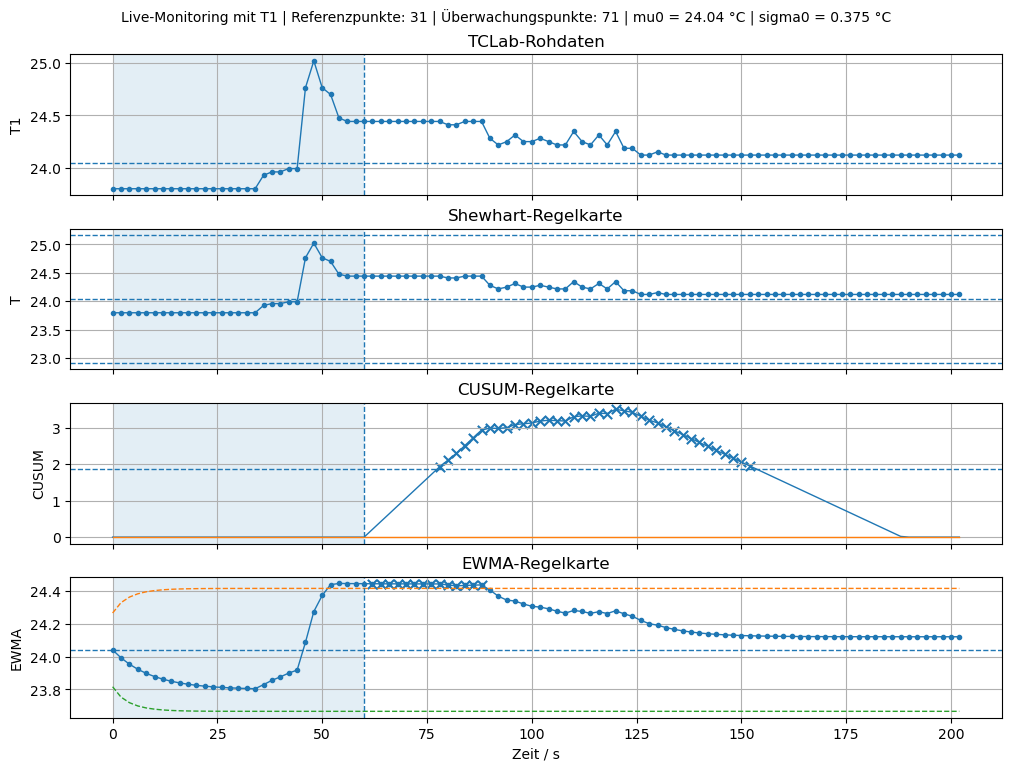

CSV-Datei gespeichert: tclab_rulecards_live.csv

Referenzmittelwert mu0 = 24.041 °C
Referenz-Standardabweichung sigma0 = 0.375 °C
Shewhart-Signale: 0
CUSUM-Signale:    38
EWMA-Signale:     14


,time_s,T1,phase,shewhart_alarm,cusum_c_plus,cusum_c_minus,cusum_alarm,ewma,ewma_alarm
92,184.00,24.121,Überwachung,False,0.234985,0.0,False,24.121170,False
93,186.00,24.121,Überwachung,False,0.127550,0.0,False,24.121136,False
94,188.00,24.121,Überwachung,False,0.020114,0.0,False,24.121109,False
95,190.00,24.121,Überwachung,False,0.000000,0.0,False,24.121087,False
96,192.01,24.121,Überwachung,False,0.000000,0.0,False,24.121070,False
97,194.00,24.121,Überwachung,False,0.000000,0.0,False,24.121056,False
98,196.00,24.121,Überwachung,False,0.000000,0.0,False,24.121045,False
99,198.00,24.121,Überwachung,False,0.000000,0.0,False,24.121036,False
100,200.00,24.121,Überwachung,False,0.000000,0.0,False,24.121029,False
101,202.00,24.121,Überwachung,False,0.000000,0.0,False,24.121023,False


In [7]:
# -----------------------------
# Live-Messung am realen TCLab
# -----------------------------
#
# Wichtig:
# - Es wird nur ein Sensor (T1) verwendet.
# - Beide Heizer bleiben ausgeschaltet.
# - Die erste Minute dient als Referenzphase.
# - Danach beginnt die Überwachung.
#
# Während der Überwachungsphase kann man kleine Störungen testen,
# z. B. leichtes Anpusten oder vorsichtiges Berühren.

times = []
values = []

print("Starte Live-Messung am realen TCLab ...")
print(f"Sensor: {sensor_name}")
print(f"Referenzphase: erste {reference_time:.0f} s")
print(f"Gesamtdauer: {experiment_duration:.0f} s")
print("Heizer bleiben ausgeschaltet (Q1 = 0, Q2 = 0).")

with TCLab() as lab:
    lab.Q1(0)
    lab.Q2(0)

    # Etwas größere Toleranz, damit das Notebook beim Plotten nicht zu schnell aus dem Takt gerät.
    for i, t in enumerate(clock(experiment_duration + sample_time, step=sample_time, tol=max(1.0, sample_time))):
        temp_value = float(getattr(lab, sensor_name))

        times.append(float(t))
        values.append(temp_value)

        result = compute_rulecards(
            times=times,
            values=values,
            reference_time=reference_time,
            lam=lambda_ewma,
            K_sigma=K_sigma,
            H_sigma=H_sigma,
        )

        if (result is not None) and (i % update_every == 0):
            plot_live_dashboard(
                result,
                sensor_name=sensor_name,
                reference_time=reference_time,
                figure_size=figure_size,
            )

    lab.Q1(0)
    lab.Q2(0)

# Abschlussauswertung
result = compute_rulecards(
    times=times,
    values=values,
    reference_time=reference_time,
    lam=lambda_ewma,
    K_sigma=K_sigma,
    H_sigma=H_sigma,
)

plot_live_dashboard(
    result,
    sensor_name=sensor_name,
    reference_time=reference_time,
    figure_size=figure_size,
)

live_df = pd.DataFrame({
    "time_s": result["time"],
    sensor_name: result["x"],
    "phase": result["phase"],
    "shewhart_alarm": result["shewhart_alarm"],
    "cusum_c_plus": result["c_plus"],
    "cusum_c_minus": result["c_minus"],
    "cusum_alarm": result["cusum_alarm"],
    "ewma": result["ewma"],
    "ewma_alarm": result["ewma_alarm"],
})

if save_csv:
    live_df.to_csv(output_csv, index=False)
    print(f"CSV-Datei gespeichert: {output_csv}")

print()
print(f"Referenzmittelwert mu0 = {result['mu0']:.3f} °C")
print(f"Referenz-Standardabweichung sigma0 = {result['sigma0']:.3f} °C")
print(f"Shewhart-Signale: {int(np.sum(result['shewhart_alarm']))}")
print(f"CUSUM-Signale:    {int(np.sum(result['cusum_alarm']))}")
print(f"EWMA-Signale:     {int(np.sum(result['ewma_alarm']))}")

display(live_df.tail(10))

## Hinweise zur Interpretation

- In der **Referenzphase** werden nur NOC-Daten gesammelt.
- Ab **$t > 60$ s** beginnt die eigentliche Überwachung.
- Die **Shewhart-Regelkarte** reagiert stärker auf einzelne größere Ausreißer.
- **CUSUM** und **EWMA** sind meist empfindlicher für kleine, anhaltende Änderungen.
